# Pramana — describe an experiment, run it, see the results

Pramana turns a plain-English description of a network experiment into a real,
measured run. You write **one sentence** describing what you want (the app, the
link speed, the latency, how long, and so on), and Pramana figures out the rest:
it configures the network, runs the application, captures the traffic, and records
the throughput and latency it actually measured.

**How to use this notebook:**

1. Edit the `INTENT` sentence in the next cell to describe your experiment.
2. Run the **Run experiment** cell and wait for the summary.
3. Run the **Show history** cell to see past experiments.

That's it, no network, API, or programming knowledge required.

In [57]:
from pramana_helpers import *  # loads the services and helper functions

# Describe your experiment in plain English:
INTENT = (
    "Run YouTube on a 6 Mbps bottleneck with 50 ms latency "
    "for 60 seconds using cubic congestion control and a pfifo queue."
)

# Optional — pin exact values by describing them in the sentence above.
# Examples you can write in plain English inside INTENT:
#   capacity:          "on a 10 Mbps link"
#   latency:           "with 20 ms latency"
#   congestion control:"using bbr"  (cubic / bbr / reno)
#   queue / AQM:       "with an fq_codel queue"  (pfifo / fq_codel / codel)
#   duration:          "for 90 seconds"
#   repeats:           "repeat 3 times"
#   concurrent apps:   "run YouTube and Zoom at the same time"

## Run experiment

In [58]:
run_and_display(INTENT)

Submitting intent to Pramana ...
  orchestration_id: orch-b6406d49
  running (shaping + capture + transfer can take a few minutes) ...
  pending ... (0s)
  executing ... (5s)
  complete ... (187s)

✓ Experiment complete
  App:        youtube
  Capacity:   6 Mbps
  Latency:    50 ms
  Throughput: 6.23 Mbps
  RTT:        299 ms


## Show history

In [59]:
show_history()

15 most recent experiment(s) in telemetry:


,when,app,status,capacity (Mbps),latency (ms),throughput (Mbps),rtt (ms)
0,2026-07-06 21:27:39,youtube,success,6,50,6.2343,298.976
1,2026-07-06 19:35:29,youtube,success,6,50,6.1445,282.828
2,2026-07-06 19:30:16,wget,success,10,20,10.3715,128.433
3,2026-07-06 19:08:36,youtube,success,6,50,6.1938,238.001
4,2026-07-06 19:04:34,youtube,success,6,50,6.1389,426.244
5,2026-07-02 20:41:14,wget,success,10,20,10.4316,14.288
6,2026-07-02 20:40:14,wget,success,10,20,10.4396,95.023
7,2026-07-02 20:38:14,wget,success,10,20,10.4474,109.021
8,2026-07-02 20:32:15,wget,success,10,20,10.452,110.873
9,2026-07-02 20:16:15,wget,success,10,20,10.438,104.981


,when,app,status,capacity (Mbps),latency (ms),throughput (Mbps),rtt (ms)
0,2026-07-06 21:27:39,youtube,success,6,50,6.2343,298.976
1,2026-07-06 19:35:29,youtube,success,6,50,6.1445,282.828
2,2026-07-06 19:30:16,wget,success,10,20,10.3715,128.433
3,2026-07-06 19:08:36,youtube,success,6,50,6.1938,238.001
4,2026-07-06 19:04:34,youtube,success,6,50,6.1389,426.244
5,2026-07-02 20:41:14,wget,success,10,20,10.4316,14.288
6,2026-07-02 20:40:14,wget,success,10,20,10.4396,95.023
7,2026-07-02 20:38:14,wget,success,10,20,10.4474,109.021
8,2026-07-02 20:32:15,wget,success,10,20,10.452,110.873
9,2026-07-02 20:16:15,wget,success,10,20,10.438,104.981


## YouTube vs. Vimeo traffic in the concurrent run

The graph below splits **download traffic** from the shared PCAP into YouTube and Vimeo using the TLS server names observed for each remote IP. YouTube includes its YouTube/Google Video CDN hosts; Vimeo includes Vimeo and Vimeo CDN hosts. Unrelated browser background traffic is deliberately left unclassified instead of being credited to either player.

,download (MiB),average during QoE window (Mbps),peak 1-second bin (Mbps),share of attributed bytes (%)
application,,,,
YouTube,1.875,1.109,1.510,69.377
Vimeo,0.828,0.490,1.025,30.623


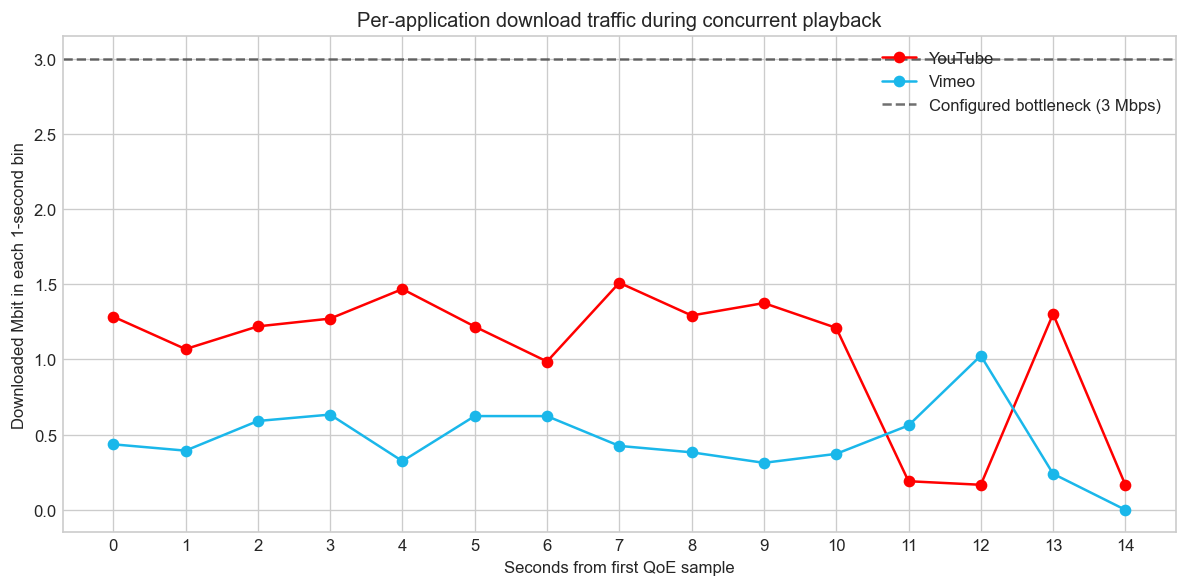

Attribution window: 14.177 seconds
App-attributed download: 2.702 MiB
Unclassified/background download excluded: 2.210 MiB


In [1]:
from pathlib import Path
import json
import math
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

result_candidates = [
    Path('youtube_vimeo_100ms_pfifo/results/3mbps'),
    Path('experiments/youtube_vimeo_100ms_pfifo/results/3mbps'),
]
RESULT_DIR = next((p.resolve() for p in result_candidates if p.is_dir()), None)
if RESULT_DIR is None:
    raise FileNotFoundError('Could not locate the 3 Mbps YouTube + Vimeo result directory')

PCAP = RESULT_DIR / 'youtube-vimeo-3mbps-100ms-pfifo.pcap'
CLIENT_IP = '172.16.1.1'

def jsonl_bounds(path):
    with path.open() as handle:
        rows = [json.loads(line) for line in handle if line.strip()]
    return rows[0]['timestamp'], rows[-1]['timestamp']

youtube_start, youtube_end = jsonl_bounds(RESULT_DIR / 'youtube_stats.jsonl')
vimeo_start, vimeo_end = jsonl_bounds(RESULT_DIR / 'vimeo_stats.jsonl')
window_start = min(youtube_start, vimeo_start)
window_end = max(youtube_end, vimeo_end)
window_seconds = window_end - window_start

# Learn remote-IP -> hostname mappings from TLS Server Name Indication in the PCAP.
sni_output = subprocess.run(
    ['tshark', '-r', str(PCAP), '-Y', 'tls.handshake.extensions_server_name',
     '-T', 'fields', '-e', 'ip.dst', '-e', 'tls.handshake.extensions_server_name'],
    check=True, capture_output=True, text=True,
).stdout
hosts_by_ip = {}
for line in sni_output.splitlines():
    fields = line.split('\t')
    if len(fields) >= 2 and fields[0] and fields[1]:
        hosts_by_ip.setdefault(fields[0], set()).update(h.lower() for h in fields[1].split(','))

youtube_markers = ('youtube.com', 'googlevideo.com', 'ytimg.com', 'ggpht.com', 'gvt1.com')
vimeo_markers = ('vimeo.com', 'vimeocdn.com')
youtube_ips = {ip for ip, hosts in hosts_by_ip.items() if any(marker in host for host in hosts for marker in youtube_markers)}
vimeo_ips = {ip for ip, hosts in hosts_by_ip.items() if any(marker in host for host in hosts for marker in vimeo_markers)}

packet_output = subprocess.run(
    ['tshark', '-r', str(PCAP), '-Y', f'ip.dst == {CLIENT_IP}', '-T', 'fields',
     '-e', 'frame.time_epoch', '-e', 'ip.src', '-e', 'frame.len'],
    check=True, capture_output=True, text=True,
).stdout
packet_rows = []
for line in packet_output.splitlines():
    fields = line.split('\t')
    if len(fields) >= 3 and all(fields[:3]):
        timestamp, remote_ip, frame_bytes = float(fields[0]), fields[1], int(fields[2].split(',')[0])
        if window_start <= timestamp <= window_end:
            app = 'YouTube' if remote_ip in youtube_ips else 'Vimeo' if remote_ip in vimeo_ips else 'Unclassified'
            packet_rows.append((timestamp, remote_ip, frame_bytes, app))

packets = pd.DataFrame(packet_rows, columns=['timestamp', 'remote_ip', 'frame_bytes', 'application'])
packets['second'] = (packets.timestamp - window_start).astype(int)
bin_count = max(1, math.ceil(window_seconds))
app_bytes = (packets[packets.application.isin(['YouTube', 'Vimeo'])]
             .groupby(['second', 'application']).frame_bytes.sum()
             .unstack(fill_value=0)
             .reindex(range(bin_count), fill_value=0)
             .reindex(columns=['YouTube', 'Vimeo'], fill_value=0))
app_mbps = app_bytes * 8 / 1_000_000

summary_rows = []
for app in ['YouTube', 'Vimeo']:
    total_bytes = app_bytes[app].sum()
    summary_rows.append({
        'application': app,
        'download (MiB)': total_bytes / 2**20,
        'average during QoE window (Mbps)': total_bytes * 8 / window_seconds / 1_000_000,
        'peak 1-second bin (Mbps)': app_mbps[app].max(),
        'share of attributed bytes (%)': 100 * total_bytes / app_bytes.to_numpy().sum(),
    })
traffic_summary = pd.DataFrame(summary_rows).set_index('application')
display(traffic_summary.round(3))

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(app_mbps.index, app_mbps['YouTube'], marker='o', color='#ff0000', label='YouTube')
ax.plot(app_mbps.index, app_mbps['Vimeo'], marker='o', color='#1ab7ea', label='Vimeo')
ax.axhline(3, color='#333333', linestyle='--', alpha=.7, label='Configured bottleneck (3 Mbps)')
ax.set(
    title='Per-application download traffic during concurrent playback',
    xlabel='Seconds from first QoE sample',
    ylabel='Downloaded Mbit in each 1-second bin',
)
ax.set_xticks(range(bin_count))
ax.legend()
plt.tight_layout()
plt.show()

attributed = app_bytes.to_numpy().sum()
unclassified = packets.loc[packets.application == 'Unclassified', 'frame_bytes'].sum()
print(f'Attribution window: {window_seconds:.3f} seconds')
print(f'App-attributed download: {attributed / 2**20:.3f} MiB')
print(f'Unclassified/background download excluded: {unclassified / 2**20:.3f} MiB')

## Buffer health during the dual run

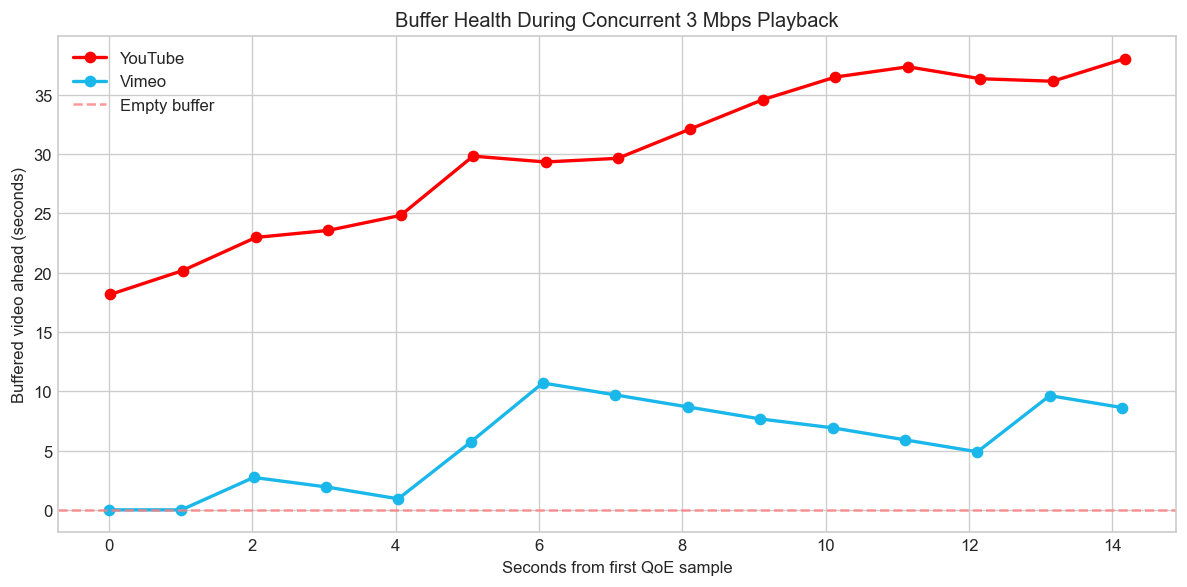

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt

result_candidates = [
    Path('youtube_vimeo_100ms_pfifo/results/3mbps'),
    Path('experiments/youtube_vimeo_100ms_pfifo/results/3mbps'),
]
RESULT_DIR = next((p.resolve() for p in result_candidates if p.is_dir()), None)
if RESULT_DIR is None:
    raise FileNotFoundError('Could not locate the 3 Mbps YouTube + Vimeo result directory')

def load_buffer_samples(app):
    with (RESULT_DIR / f'{app}_stats.jsonl').open() as handle:
        rows = [json.loads(line) for line in handle if line.strip()]
    return rows

youtube_buffer = load_buffer_samples('youtube')
vimeo_buffer = load_buffer_samples('vimeo')
start_time = min(youtube_buffer[0]['timestamp'], vimeo_buffer[0]['timestamp'])

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
for name, rows, color in [
    ('YouTube', youtube_buffer, '#ff0000'),
    ('Vimeo', vimeo_buffer, '#1ab7ea'),
]:
    seconds = [row['timestamp'] - start_time for row in rows]
    buffer_health = [row['stats'].get('buffer_ahead_secs', 0) or 0 for row in rows]
    ax.plot(seconds, buffer_health, marker='o', linewidth=2, label=name, color=color)

ax.axhline(0, color='#ff7f7f', linestyle='--', alpha=.8, label='Empty buffer')
ax.set(
    title='Buffer Health During Concurrent 3 Mbps Playback',
    xlabel='Seconds from first QoE sample',
    ylabel='Buffered video ahead (seconds)',
)
ax.legend()
plt.tight_layout()
plt.show()